In [31]:
# spectrogram_visualizer.ipynb

# This code allows the user to visualize the spectrogram of an audio file containing a given animal.
# The user types in a primary label.

import librosa
import numpy as np
import pandas as pd
import pickle
import os

In [32]:
import random
from pathlib import Path

def choose_file(primary_label):
    folder = Path(f'train_audio/{primary_label}')
    files = list(folder.glob('*'))
    file = random.choice(files)
    return file

In [33]:
# Creates a mel spectrogram from an audio file and converts it to decibels.

def create_spectrogram(file):
    y, sr = librosa.load(file)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    return S_dB

In [39]:
taxonomy_df = pd.read_csv("taxonomy.csv")
classes = ['Insecta', 'Reptilia', 'Amphibia', 'Mammalia', 'Aves']

def find_info(primary_label):
    for row in taxonomy_df.itertuples():
        if row.primary_label == primary_label:
            return row.common_name

In [40]:
import matplotlib.pyplot as plt

def visualize(primary_label):
    file = choose_file(primary_label)
    spectrogram = create_spectrogram(file)
    plt.imshow(spectrogram.squeeze(), aspect='auto')
    plt.title(find_info(primary_label) + " Sample")
    plt.xlabel("Time (s)")
    plt.ylabel("Relative frequency")
    plt.show()

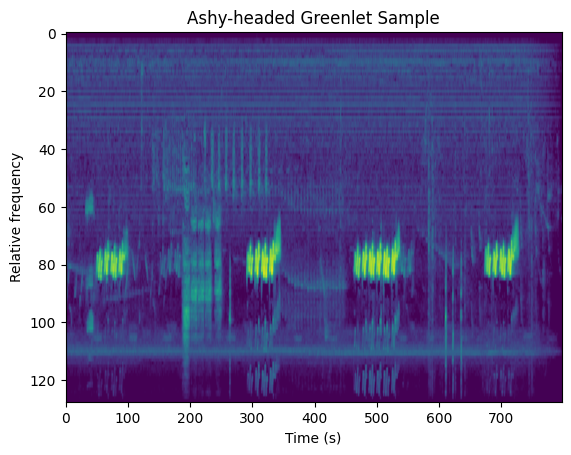

In [41]:
visualize('ashgre1')

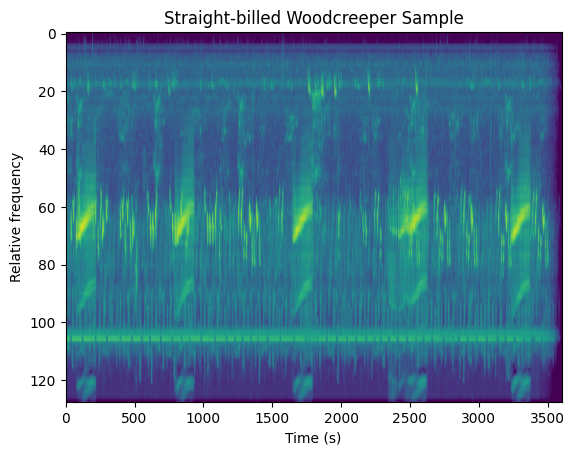

In [42]:
visualize('stbwoo2')

In [ ]:
visualize('platyr1')